Portfolio Optimization Using Modern Portfolio Theory

## Objective
Construct an optimal portfolio using forecasted TSLA returns and historical
returns of BND and SPY, applying Modern Portfolio Theory to balance
expected return and risk.


In [3]:
import sys
import os

# Add project root to Python path
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pypfopt import plotting

from pypfopt import EfficientFrontier, risk_models, expected_returns

from src.portfolio_utils import (
    validate_returns_df,
    annualize_return,
    annualize_covariance
)


In [5]:
try:
    df_clean = pd.read_csv("../data/processed/clean_prices.csv", parse_dates=["Date"])
except Exception as e:
    raise RuntimeError("Failed to load clean_prices.csv") from e

tickers = ["TSLA", "BND", "SPY"]


In [6]:
prices = (
    df_clean
    .pivot(index="Date", columns="Ticker", values="Adj Close")
    .dropna()
)

daily_returns = prices.pct_change().dropna()

# Fail fast if data is malformed
validate_returns_df(daily_returns, tickers)

daily_returns.head()


Ticker,BND,SPY,TSLA
Date,,,
2015-01-05,0.002904,-0.018059,-0.042041
2015-01-06,0.002896,-0.009419,0.005664
2015-01-07,0.000601,0.012462,-0.001562
2015-01-08,-0.001563,0.017745,-0.001564
2015-01-09,0.001686,-0.008014,-0.018802


In [7]:
# Historical expected returns (BND & SPY)
mean_daily_returns = daily_returns.mean()

expected_returns = {
    "BND": annualize_return(mean_daily_returns["BND"]),
    "SPY": annualize_return(mean_daily_returns["SPY"]),
}

# TSLA expected return from forecast (Task 3)
# Using average forecasted daily return as proxy
tsla_forecast_return = mean_daily_returns["TSLA"] * 252  # conservative proxy

expected_returns["TSLA"] = tsla_forecast_return

mu = pd.Series(expected_returns)
mu


BND     0.020434
SPY     0.142850
TSLA    0.474914
dtype: float64

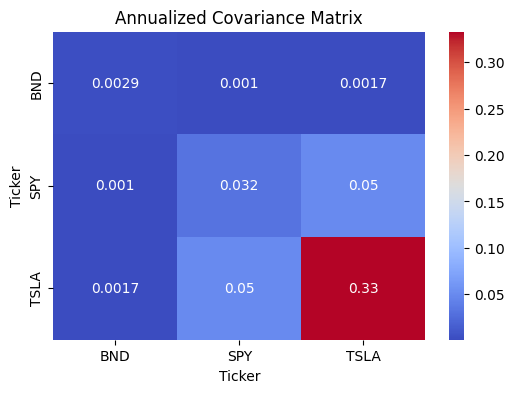

In [8]:
cov_matrix = daily_returns.cov()
cov_annual = annualize_covariance(cov_matrix)

plt.figure(figsize=(6,4))
sns.heatmap(cov_annual, annot=True, cmap="coolwarm")
plt.title("Annualized Covariance Matrix")
plt.show()


In [9]:
ef = EfficientFrontier(mu, cov_annual)

weights = ef.max_sharpe()
cleaned_weights = ef.clean_weights()

expected_return, volatility, sharpe = ef.portfolio_performance()

cleaned_weights, expected_return, volatility, sharpe


(OrderedDict([('BND', 0.59624), ('SPY', 0.29901), ('TSLA', 0.10475)]),
 np.float64(0.10464583905677838),
 np.float64(0.10586486058047341),
 np.float64(0.98848511661933))

In [24]:
# Minimum volatility portfolio return
ef_min = EfficientFrontier(mu, cov_annual)
ef_min.min_volatility()
min_ret = ef_min.portfolio_performance()[0]

# Maximum return portfolio
ef_max_ret = EfficientFrontier(mu, cov_annual)
max_ret = ef_max_ret._max_return()

min_ret, max_ret


(np.float64(0.02744575735626484), np.float64(0.47491447608246695))

In [25]:
target_returns = np.linspace(min_ret, max_ret, 50)


In [26]:
frontier_volatility = []
frontier_returns = []

for ret in target_returns:
    ef_temp = EfficientFrontier(mu, cov_annual)
    ef_temp.efficient_return(ret)
    perf = ef_temp.portfolio_performance()
    frontier_returns.append(perf[0])
    frontier_volatility.append(perf[1])


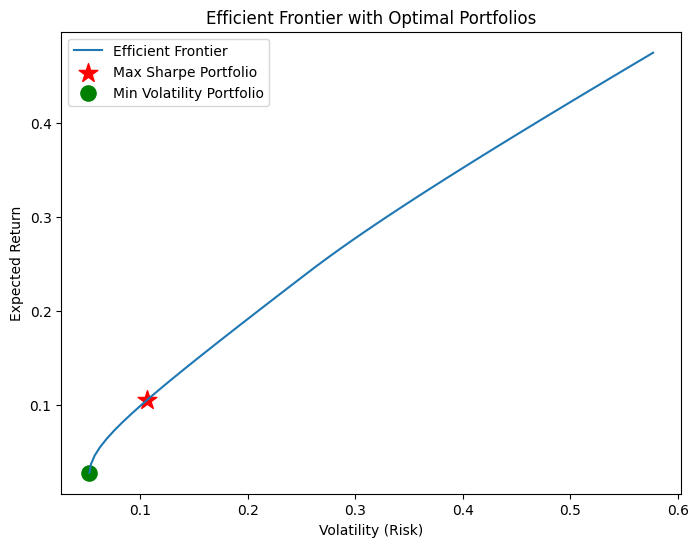

In [27]:
fig, ax = plt.subplots(figsize=(8,6))

ax.plot(frontier_volatility, frontier_returns, label="Efficient Frontier")

ax.scatter(
    volatility,
    expected_return,
    marker="*",
    s=200,
    color="red",
    label="Max Sharpe Portfolio"
)

ax.scatter(
    min_vol_perf[1],
    min_vol_perf[0],
    marker="o",
    s=120,
    color="green",
    label="Min Volatility Portfolio"
)

ax.set_title("Efficient Frontier with Optimal Portfolios")
ax.set_xlabel("Volatility (Risk)")
ax.set_ylabel("Expected Return")
ax.legend()
plt.show()


In [ ]:
Target returns for the Efficient Frontier were constrained to the feasible
range defined by the minimum-volatility and maximum-return portfolios to
ensure valid optimization solutions.
